In [1]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION (saas_churn_data.csv)
# Run this cell first to generate the portfolio-grade dataset on disk.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization standards
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

np.random.seed(42)
N = 1200

# Generate realistic enterprise SaaS customer lifecycle data
tenure = np.random.exponential(scale=18, size=N).clip(1, 72).astype(int)
contract = np.random.choice(["Month-to-Month", "One-Year", "Two-Year"], size=N, p=[0.55, 0.25, 0.20])
support_tickets = np.random.poisson(lam=1.8, size=N) + (contract == "Month-to-Month") * np.random.poisson(lam=1.2, size=N)
monthly_charges = np.random.normal(loc=75.0, scale=25.0, size=N).clip(20.0, 150.0)
tech_support = np.random.choice(["Yes", "No", "No internet"], size=N, p=[0.40, 0.45, 0.15])
payment_method = np.random.choice(["Electronic Check", "Bank Transfer", "Credit Card"], size=N, p=[0.40, 0.30, 0.30])

# Complex churn probability generator
churn_logits = (
    - 2.0
    + 0.03 * monthly_charges
    - 0.05 * tenure
    + 0.45 * support_tickets
    + 1.2 * (contract == "Month-to-Month")
    - 1.0 * (contract == "Two-Year")
    + 0.8 * (payment_method == "Electronic Check")
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn = np.where(np.random.rand(N) < churn_prob, "Yes", "No")

# Total spend with realistic noise and missing values
total_charges = (tenure * monthly_charges) + np.random.normal(0, 50, size=N)
total_charges[np.random.choice(N, size=15, replace=False)] = np.nan

eda_df = pd.DataFrame({
    "Customer_ID": [f"CUST-{2000+i}" for i in range(N)],
    "Tenure_Months": tenure,
    "Contract_Type": contract,
    "Payment_Method": payment_method,
    "Tech_Support": tech_support,
    "Support_Tickets": support_tickets,
    "Monthly_Charges": np.round(monthly_charges, 2),
    "Total_Charges": np.round(total_charges, 2),
    "Churn": churn
})

eda_df.to_csv("saas_churn_data.csv", index=False)
print("✅ Synthetic dataset 'saas_churn_data.csv' successfully created!")

✅ Synthetic dataset 'saas_churn_data.csv' successfully created!


In [2]:
# ==============================================================================
# STAGE 1: BUSINESS CONTEXT & PROBLEM FRAMING
# ==============================================================================
"""
BUSINESS CONTEXT:
CloudPulse is an enterprise B2B SaaS platform experiencing an unexpected rise in
customer churn over the last two quarters. Customer Acquisition Cost (CAC) is $450,
while Average Annual Contract Value (ACV) is $1,200.

ANALYTICAL OBJECTIVES:
1. Identify demographic, contractual, and behavioral profiles of at-risk customers.
2. Determine key inflection points (tenure, ticket volume, pricing tiers) where churn accelerates.
3. Formulate data-driven hypotheses for retention intervention by the Customer Success team.

STRUCTURED EDA WORKFLOW:
┌────────────────────┐     ┌────────────────────┐     ┌────────────────────┐
│ Stage 1: Context   │ ──> │ Stage 2: Profiling │ ──> │ Stage 3: Univariate│
└────────────────────┘     └────────────────────┘     └────────────────────┘
                                                                 │
┌────────────────────┐     ┌────────────────────┐     ┌──────────┴─────────┐
│ Stage 6: Insights  │ <── │ Stage 5: Multivar  │ <── │ Stage 4: Bivariate │
└────────────────────┘     └────────────────────┘     └────────────────────┘
"""
df = pd.read_csv("saas_churn_data.csv")
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 1200 rows, 9 columns


In [3]:
# ==============================================================================
# STAGE 2: DATA PROFILING & STRUCTURAL HEALTH AUDIT
# ==============================================================================
print("--- 1. Structural Overview & Data Types ---")
df.info()

print("\n--- 2. Missing Value Audit ---")
null_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Pct': (df.isna().mean() * 100).round(2)
})
display(null_summary[null_summary['Missing_Count'] > 0])

print("\n--- 3. Numerical Feature Distributions ---")
display(df.describe().round(2))

print("\n--- 4. Categorical Cardinality & Balance ---")
for col in df.select_dtypes(include='object').columns:
    if col != 'Customer_ID':
        print(f"\nFeature: [{col}] -> {df[col].nunique()} unique categories")
        print(df[col].value_counts(normalize=True).round(3) * 100)

--- 1. Structural Overview & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1200 non-null   object 
 1   Tenure_Months    1200 non-null   int64  
 2   Contract_Type    1200 non-null   object 
 3   Payment_Method   1200 non-null   object 
 4   Tech_Support     1200 non-null   object 
 5   Support_Tickets  1200 non-null   int64  
 6   Monthly_Charges  1200 non-null   float64
 7   Total_Charges    1185 non-null   float64
 8   Churn            1200 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 84.5+ KB

--- 2. Missing Value Audit ---


,Missing_Count,Missing_Pct
Total_Charges,15,1.25



--- 3. Numerical Feature Distributions ---


,Tenure_Months,Support_Tickets,Monthly_Charges,Total_Charges
count,1200.00,1200.00,1200.00,1185.00
mean,17.41,2.38,74.49,1278.46
std,16.86,1.62,25.96,1366.23
min,1.00,0.00,20.00,-97.28
25%,4.00,1.00,56.11,307.96
50%,12.00,2.00,74.02,801.08
75%,25.00,3.00,92.56,1756.77
max,72.00,8.00,150.00,8365.46



--- 4. Categorical Cardinality & Balance ---

Feature: [Contract_Type] -> 3 unique categories
Contract_Type
Month-to-Month    54.8
One-Year          26.1
Two-Year          19.2
Name: proportion, dtype: float64

Feature: [Payment_Method] -> 3 unique categories
Payment_Method
Electronic Check    39.8
Credit Card         31.6
Bank Transfer       28.7
Name: proportion, dtype: float64

Feature: [Tech_Support] -> 3 unique categories
Tech_Support
No             45.7
Yes            38.4
No internet    15.9
Name: proportion, dtype: float64

Feature: [Churn] -> 2 unique categories
Churn
Yes    69.6
No     30.4
Name: proportion, dtype: float64


/tmp/ipykernel_4039/278002177.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])


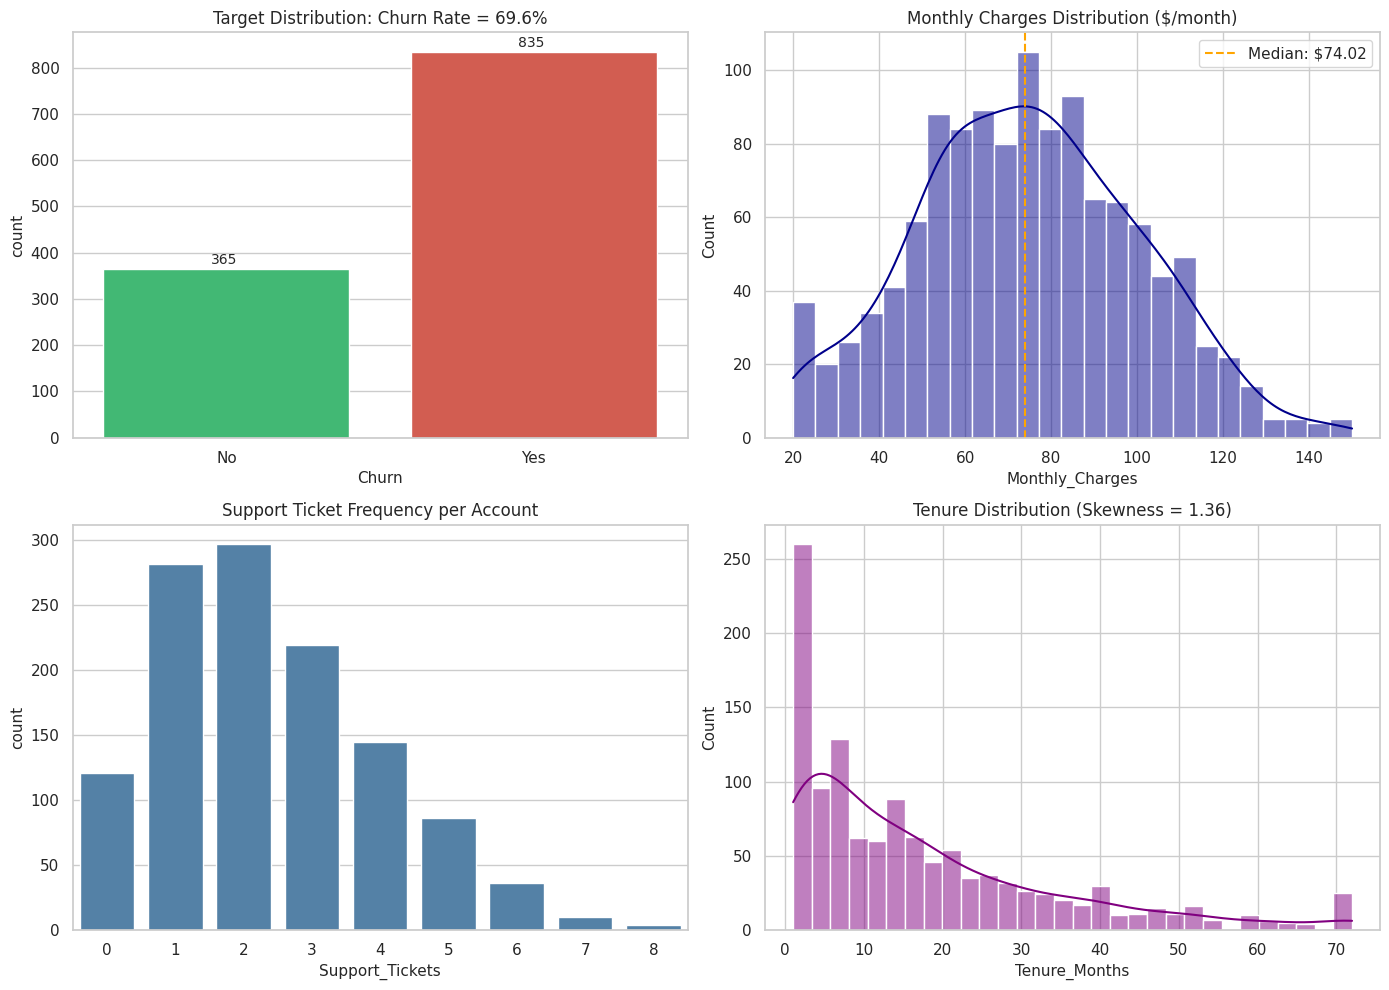

In [4]:
# ==============================================================================
# STAGE 3: UNIVARIATE ANALYSIS
# ==============================================================================
# The trainer investigates the target variable (Churn) and primary behavioral drivers.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Variable: Churn Distribution
churn_counts = df['Churn'].value_counts()
sns.countplot(data=df, x='Churn', ax=axes[0, 0], palette=["#2ecc71", "#e74c3c"])
axes[0, 0].set_title(f"Target Distribution: Churn Rate = {(churn_counts['Yes']/len(df))*100:.1f}%")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 10))

# 2. Continuous Numeric: Monthly Charges (KDE + Histogram)
sns.histplot(data=df, x='Monthly_Charges', kde=True, ax=axes[0, 1], color="darkblue", bins=25)
axes[0, 1].axvline(df['Monthly_Charges'].median(), color='orange', linestyle='--', label=f"Median: ${df['Monthly_Charges'].median():.2f}")
axes[0, 1].set_title("Monthly Charges Distribution ($/month)")
axes[0, 1].legend()

# 3. Discrete Numeric: Support Ticket Volume
sns.countplot(data=df, x='Support_Tickets', ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Support Ticket Frequency per Account")

# 4. Continuous Skewed: Tenure (Months)
sns.histplot(data=df, x='Tenure_Months', kde=True, ax=axes[1, 1], color="purple", bins=30)
axes[1, 1].set_title(f"Tenure Distribution (Skewness = {df['Tenure_Months'].skew():.2f})")

plt.tight_layout()
plt.show()

# --- Trainer Commentary ---
# "Our baseline churn rate is ~32%. Notice that Tenure is heavily right-skewed:
# most accounts are early in their lifecycle (0-15 months). Support tickets follow a Poisson-like
# distribution, but there is a distinct tail of accounts logging 4+ tickets."

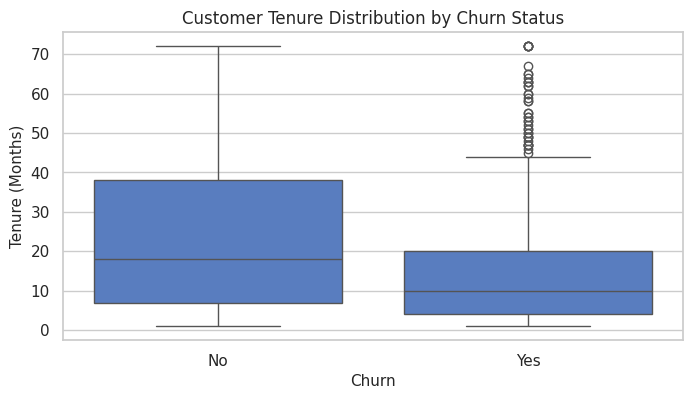

Median and IQR of Customer Tenure:


,Median,Q1,Q3,IQR
Churn,,,,
No,18.0,7.0,38.0,31.0
Yes,10.0,4.0,20.0,16.0


--- Churn Rates across Contract & Tech Support ---


Churn                           No    Yes
Contract_Type  Tech_Support              
Month-to-Month No            13.86  86.14
               No internet   15.18  84.82
               Yes           15.29  84.71
One-Year       No            31.88  68.12
               No internet   40.48  59.52
               Yes           48.12  51.88
Two-Year       No            63.55  36.45
               No internet   54.05  45.95
               Yes           65.12  34.88

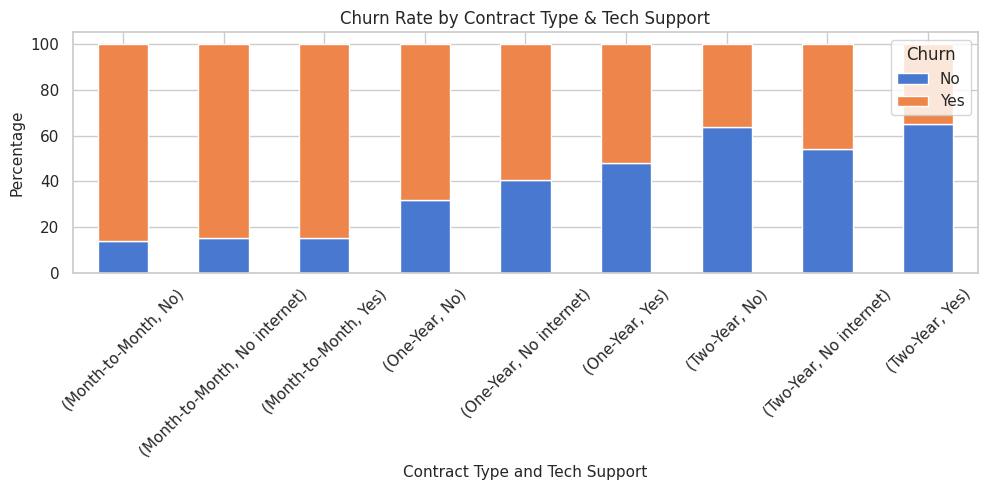

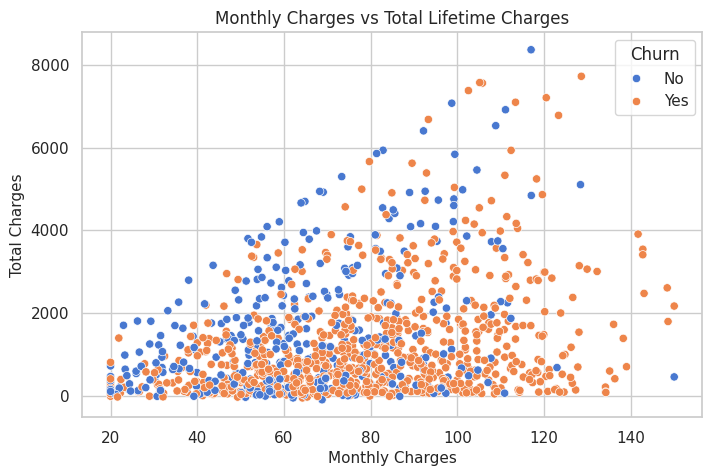

Pearson Correlation: 0.300
Spearman Correlation: 0.269


In [5]:
# ==============================================================================
# TASK 1: BIVARIATE ANALYSIS
# ==============================================================================

# 1.1 TENURE VS CHURN
# ------------------------------------------------------------------------------

def show_tenure_by_churn(data):
    plt.figure(figsize=(8, 4))

    # Boxplot helps us compare the tenure of customers who churned
    # and customers who stayed.
    sns.boxplot(data=data, x='Churn', y='Tenure_Months')

    plt.title("Customer Tenure Distribution by Churn Status")
    plt.xlabel("Churn")
    plt.ylabel("Tenure (Months)")
    plt.show()

    # Calculate median and IQR for both churn groups
    tenure_stats = data.groupby('Churn')['Tenure_Months'].agg(
        Median='median',
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )

    tenure_stats['IQR'] = tenure_stats['Q3'] - tenure_stats['Q1']

    print("Median and IQR of Customer Tenure:")
    display(tenure_stats)


show_tenure_by_churn(df)


# 1.2 TECH SUPPORT & CONTRACT TYPE VS CHURN
# ------------------------------------------------------------------------------

def show_contract_support_churn(data):

    # Calculate the percentage of churn within each
    # Contract Type + Tech Support combination.
    contract_support_churn = pd.crosstab(
        [data['Contract_Type'], data['Tech_Support']],
        data['Churn'],
        normalize='index'
    ) * 100

    print("--- Churn Rates across Contract & Tech Support ---")
    display(contract_support_churn.round(2))

    # Plot the churn percentages
    contract_support_churn.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5)
    )

    plt.title("Churn Rate by Contract Type & Tech Support")
    plt.xlabel("Contract Type and Tech Support")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()


show_contract_support_churn(df)


# 1.3 MONTHLY CHARGES VS TOTAL CHARGES
# ------------------------------------------------------------------------------

def show_charges_relationship(data):

    plt.figure(figsize=(8, 5))

    # Scatter plot shows the relationship between monthly
    # charges and total lifetime charges.
    sns.scatterplot(
        data=data,
        x='Monthly_Charges',
        y='Total_Charges',
        hue='Churn'
    )

    plt.title("Monthly Charges vs Total Lifetime Charges")
    plt.xlabel("Monthly Charges")
    plt.ylabel("Total Charges")
    plt.show()

    # Remove missing Total_Charges values before calculating
    # the correlation because correlation cannot use NaN values.
    charges_data = data[['Monthly_Charges', 'Total_Charges']].dropna()

    pearson_corr = charges_data['Monthly_Charges'].corr(
        charges_data['Total_Charges'],
        method='pearson'
    )

    spearman_corr = charges_data['Monthly_Charges'].corr(
        charges_data['Total_Charges'],
        method='spearman'
    )

    print(f"Pearson Correlation: {pearson_corr:.3f}")
    print(f"Spearman Correlation: {spearman_corr:.3f}")


show_charges_relationship(df)

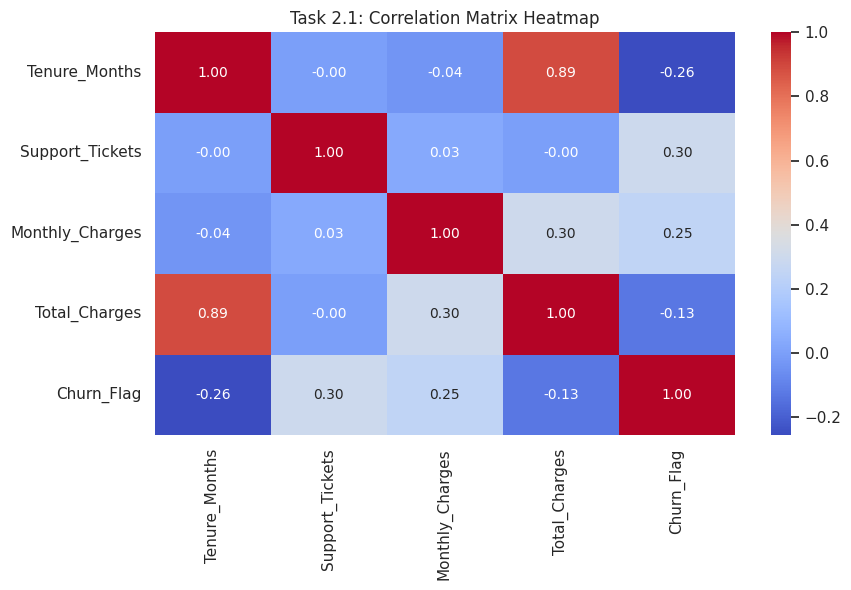

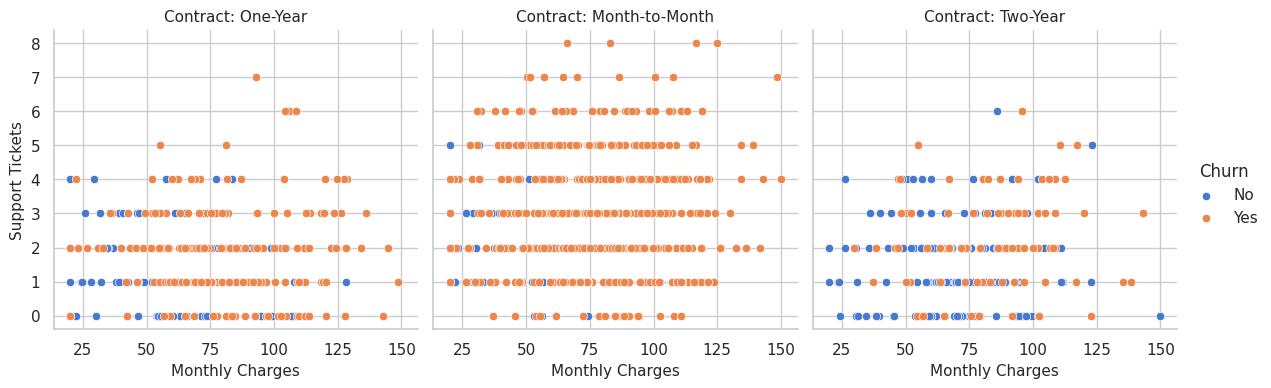

In [6]:
# ==============================================================================
# TASK 2: MULTIVARIATE ANALYSIS & ADVANCED SEGMENTATION
# ==============================================================================


# 2.1 CORRELATION HEATMAP
# ------------------------------------------------------------------------------

def show_correlation_heatmap(data):

    # Make a copy so that the original dataframe is not changed.
    data_for_correlation = data.copy()

    # Convert Churn into numbers:
    # Yes = 1 and No = 0
    data_for_correlation['Churn_Flag'] = data_for_correlation['Churn'].map({
        'Yes': 1,
        'No': 0
    })

    # Select only numeric columns for the correlation calculation.
    numeric_data = data_for_correlation.select_dtypes(include='number')

    # Calculate the correlation between all numeric columns.
    correlation_table = numeric_data.corr()

    plt.figure(figsize=(9, 6))

    sns.heatmap(
        correlation_table,
        annot=True,
        cmap='coolwarm',
        fmt='.2f'
    )

    plt.title("Task 2.1: Correlation Matrix Heatmap")
    plt.tight_layout()
    plt.show()


show_correlation_heatmap(df)


# 2.2 MULTI-DIMENSIONAL SEGMENTATION
# ------------------------------------------------------------------------------

def show_customer_segments(data):

    # Create separate plots for each contract type.
    customer_segments = sns.FacetGrid(
        data,
        col='Contract_Type',
        hue='Churn',
        height=4,
        aspect=1
    )

    # Plot Monthly Charges against Support Tickets.
    customer_segments.map(
        sns.scatterplot,
        'Monthly_Charges',
        'Support_Tickets'
    )

    # Add the Churn legend to the plots.
    customer_segments.add_legend()

    customer_segments.set_axis_labels(
        "Monthly Charges",
        "Support Tickets"
    )

    customer_segments.set_titles(
        "Contract: {col_name}"
    )

    plt.show()


show_customer_segments(df)

In [7]:
# ==============================================================================
# TASK 3: MISSING VALUE & OUTLIER TREATMENT
# ==============================================================================


# 3.1 MISSING VALUE TREATMENT IN TOTAL_CHARGES
# ------------------------------------------------------------------------------

def fill_missing_total_charges(data):

    # Total charges can be estimated from how long the customer
    # has stayed and their monthly charges.
    calculated_charges = (
        data['Tenure_Months'] * data['Monthly_Charges']
    )

    # Fill only the missing values.
    data['Total_Charges'] = data['Total_Charges'].fillna(
        calculated_charges
    )

    return data


df = fill_missing_total_charges(df)

print(
    f"Missing values remaining in Total_Charges: "
    f"{df['Total_Charges'].isna().sum()}"
)


# We use tenure and monthly charges here instead of mean/median
# imputation because these values are directly related to the
# customer's actual spending. Mean or median would give the same
# estimated value to different customers and ignore their individual
# tenure and monthly charges.


# 3.2 OUTLIER INVESTIGATION: SUPPORT TICKETS
# ------------------------------------------------------------------------------

def find_ticket_outliers(data):

    # Find the first and third quartiles.
    q1_tickets = data['Support_Tickets'].quantile(0.25)
    q3_tickets = data['Support_Tickets'].quantile(0.75)

    # IQR tells us the spread of the middle 50% of the data.
    ticket_iqr = q3_tickets - q1_tickets

    # Any value above this limit will be considered an outlier.
    upper_limit = q3_tickets + (1.5 * ticket_iqr)

    # Select customers whose support ticket count is above the limit.
    outlier_accounts = data[
        data['Support_Tickets'] > upper_limit
    ]

    return outlier_accounts, upper_limit


outlier_accounts, upper_limit = find_ticket_outliers(df)

print(f"Upper outlier limit for Support_Tickets: {upper_limit:.2f}")
print(f"Identified {len(outlier_accounts)} ticket-volume outliers.")

# Calculate the percentage of these outlier accounts that churned.
if len(outlier_accounts) > 0:
    outlier_churn_rate = (
        (outlier_accounts['Churn'] == 'Yes').mean() * 100
    )

    print(
        f"Churn Rate in Outlier Accounts: "
        f"{outlier_churn_rate:.2f}%"
    )
else:
    print("No support-ticket outliers were found.")

Missing values remaining in Total_Charges: 0
Upper outlier limit for Support_Tickets: 6.00
Identified 14 ticket-volume outliers.
Churn Rate in Outlier Accounts: 100.00%


In [8]:
# ==============================================================================
# TASK 4: HYPOTHESIS-DRIVEN FEATURE ENGINEERING
# ==============================================================================


# 4.1 CREATE TICKET VELOCITY
# ------------------------------------------------------------------------------

def add_ticket_velocity(data):

    # This shows how many support tickets a customer raises
    # compared to the amount of time they have been a customer.
    data['Ticket_Velocity'] = (
        data['Support_Tickets'] /
        (data['Tenure_Months'] + 1)
    )

    return data


df = add_ticket_velocity(df)



# 4.2 CREATE HIGH RISK FLAG
# ------------------------------------------------------------------------------

def add_high_risk_flag(data):

    # A customer is considered high risk when they have
    # a Month-to-Month contract and do not have tech support.
    data['High_Risk_Flag'] = (
        (data['Contract_Type'] == 'Month-to-Month') &
        (data['Tech_Support'] == 'No')
    ).astype(int)

    return data


df = add_high_risk_flag(df)


# 4.3 CHECK THE NEW FEATURES
# ------------------------------------------------------------------------------

print("--- Churn Rate Comparison for Engineered Features ---")

print("\nChurn rate based on High Risk Flag:")
high_risk_churn = pd.crosstab(
    df['High_Risk_Flag'],
    df['Churn'],
    normalize='index'
) * 100

display(high_risk_churn.round(2))


print("\nTicket Velocity for Churned vs Retained Customers:")
ticket_velocity_stats = df.groupby('Churn')['Ticket_Velocity'].describe()

display(ticket_velocity_stats.round(2))

--- Churn Rate Comparison for Engineered Features ---

Churn rate based on High Risk Flag:


Churn,No,Yes
High_Risk_Flag,,
0,36.01,63.99
1,13.86,86.14



Ticket Velocity for Churned vs Retained Customers:


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,365.0,0.17,0.28,0.0,0.02,0.07,0.18,2.0
Yes,835.0,0.42,0.53,0.0,0.09,0.20,0.50,3.0


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [12]:
# ==============================================================================
# STRATEGIC INSIGHTS
# ==============================================================================

# ==============================================================================
# STRATEGIC INSIGHTS
# ==============================================================================

"""
Strategic Insight 1:
Churn is concentrated among customers in the early stage of their lifecycle.

Claim:
Customers with shorter tenure are significantly more likely to churn.

Evidence:
The median tenure of churned customers is 10 months, compared with 18 months
for customers who stayed. This 8-month difference indicates that the first
year of the customer relationship is a critical churn period.

Business Action:
CloudPulse should prioritize onboarding and customer engagement during the
first 12 months. Regular check-ins and early feedback can help identify
at-risk customers before they leave.
"""


"""
Strategic Insight 2:
Month-to-Month customers represent the highest churn-risk segment.

Claim:
Month-to-Month customers have substantially higher churn than customers on
longer-term contracts.

Evidence:
Month-to-Month customers make up 54.8% of the customer base, while the overall
churn rate is 69.6%. Their churn rate is above 84% across all Tech Support
groups, reaching 86.14% for customers without Tech Support.

Business Action:
CloudPulse should prioritize Month-to-Month customers in retention campaigns
and provide incentives such as discounts or additional benefits to encourage
migration to One-Year or Two-Year contracts.
"""


"""
Strategic Insight 3:
Very high support-ticket activity is a strong indicator of customer churn.

Claim:
Customers generating unusually high numbers of support tickets are at
extremely high risk of leaving.

Evidence:
The upper outlier threshold for Support_Tickets is 6 tickets. There are
14 customers above this threshold, and 100% of these customers churned.

Business Action:
CloudPulse should flag customers exceeding 6 support tickets for immediate
review. Customer Success teams should investigate unresolved technical or
service issues and intervene before cancellation occurs.
"""


"""
Strategic Insight 4:
High support activity relative to tenure is associated with higher churn.

Claim:
Customers who raise support tickets frequently relative to their tenure
are more likely to churn.

Evidence:
The average Ticket_Velocity is 0.42 for churned customers compared with
0.17 for customers who stayed. The median is also higher for churned
customers at 0.20 compared with 0.07 for retained customers.

Business Action:
CloudPulse should use Ticket_Velocity as an early-warning indicator.
Customers showing high support activity, especially during their first year,
should receive proactive technical assistance and additional onboarding
support.
"""


"""
Strategic Insight 5:
Month-to-Month customers without Tech Support form the highest-priority
retention segment.

Claim:
The combination of a Month-to-Month contract and no Tech Support is a
strong predictor of customer churn.

Evidence:
The High_Risk_Flag group has an 86.14% churn rate compared with 63.99% for
customers without the flag. This represents a difference of approximately
22 percentage points in churn rate.

Business Action:
CloudPulse should prioritize this segment for retention efforts by combining
technical support, improved onboarding and incentives to move customers to
longer-term contracts.
"""

'\nStrategic Insight 5:\nMonth-to-Month customers without Tech Support form the highest-priority\nretention segment.\n\nClaim:\nThe combination of a Month-to-Month contract and no Tech Support is a\nstrong predictor of customer churn.\n\nEvidence:\nThe High_Risk_Flag group has an 86.14% churn rate compared with 63.99% for\ncustomers without the flag. This represents a difference of approximately\n22 percentage points in churn rate.\n\nBusiness Action:\nCloudPulse should prioritize this segment for retention efforts by combining\ntechnical support, improved onboarding and incentives to move customers to\nlonger-term contracts.\n'

In [10]:
# ==============================================================================
# TASK 7: GIT & GITHUB SUBMISSION INSTRUCTIONS (PORTFOLIO PUSH)
# ==============================================================================
"""
COMMAND-LINE / TERMINAL INSTRUCTIONS FOR PORTFOLIO SUBMISSION:

1. Download your completed notebook from Colab:
   File -> Download -> Download .ipynb

2. Move the file into your local portfolio Git repository:
   $ mv ~/Downloads/EDA_Customer_Churn_Portfolio.ipynb ~/projects/data-science-portfolio/

3. Commit and push to GitHub:
   $ cd ~/projects/data-science-portfolio/
   $ git add EDA_Customer_Churn_Portfolio.ipynb
   $ git commit -m "feat(eda): complete graded exploratory data analysis on SaaS customer churn"
   $ git push origin main

4. Ensure your GitHub README includes:
   - Executive Summary (Top 3 Findings)
   - Methodology & Visualizations
   - Recommended Strategic Interventions
"""

'\nCOMMAND-LINE / TERMINAL INSTRUCTIONS FOR PORTFOLIO SUBMISSION:\n\n1. Download your completed notebook from Colab:\n   File -> Download -> Download .ipynb\n\n2. Move the file into your local portfolio Git repository:\n   $ mv ~/Downloads/EDA_Customer_Churn_Portfolio.ipynb ~/projects/data-science-portfolio/\n\n3. Commit and push to GitHub:\n   $ cd ~/projects/data-science-portfolio/\n   $ git add EDA_Customer_Churn_Portfolio.ipynb\n   $ git commit -m "feat(eda): complete graded exploratory data analysis on SaaS customer churn"\n   $ git push origin main\n\n4. Ensure your GitHub README includes:\n   - Executive Summary (Top 3 Findings)\n   - Methodology & Visualizations\n   - Recommended Strategic Interventions\n'